In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
TEST_YEAR = '2023'

train_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_WNV_Dataset_GRID_OP_2023.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(52992, 91)


In [2]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [3]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2023,1,21.76334,40.79806,0.429337,0.049938,-0.379890,-0.049938,0.412633,0.040249,-0.369626,-0.040249,0.035814,0.041141,0.020699,0.041141,8.781818,8.044074,8.507143,13.895161,15.713571,2.680909,1.112963,-0.015714,4.273226,4.140000,5.731364,4.578519,4.245714,9.084194,9.926786,-4.73,11.23,0.101229,0.0,0.0,3.138091,9.970593,14.000000,21.833333,48.518519,876.978283,36.0,-9.0,45.0,24.666667,4.666667,24.666667,3.166667,1205.0,182.0,3.0,61.218396,493.0,94.0,493.0,173.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2
1,1,EL52,EL524,εδεσσας,2023,1,21.76334,40.81603,0.481732,0.065577,-0.431623,-0.065577,0.301485,-0.008289,-0.267576,0.008289,0.099088,0.028557,0.092640,0.028557,9.913636,8.684074,8.967857,15.106774,17.157143,1.774545,-0.477407,-1.907857,2.356452,2.577143,5.844091,4.103333,3.530000,8.731613,9.867143,-6.13,12.35,0.077243,0.0,0.0,2.394536,13.864181,12.708333,23.083333,50.181159,759.023995,34.0,-12.0,46.0,22.333333,4.166667,22.333333,3.166667,1246.0,242.0,2.0,65.733663,504.0,51.0,504.0,127.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2
2,2,EL52,EL524,εδεσσας,2023,1,21.76334,40.83400,0.323883,-0.024246,-0.356536,0.024246,0.211347,0.022864,-0.111797,-0.022864,0.066343,0.051593,0.078738,0.051593,9.838182,6.318889,6.463571,15.433871,15.328571,1.182727,-1.719630,-3.611429,1.156452,1.254286,5.510455,2.299630,1.426071,8.295161,8.291429,-4.41,13.21,0.077243,0.0,0.0,2.394536,13.864181,11.958333,22.416667,48.731884,754.217937,33.0,-13.0,46.0,21.166667,5.500000,21.166667,2.333333,1246.0,242.0,2.0,65.733663,504.0,51.0,504.0,268.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2
3,3,EL52,EL524,εδεσσας,2023,1,21.76334,40.85196,0.244375,-0.091326,-0.204051,0.091326,0.245486,-0.059192,-0.236298,0.059192,0.051444,0.043485,0.079051,0.043485,8.446364,6.254444,5.096429,13.691935,15.582143,1.777273,-1.861852,1.691429,2.028065,4.946429,5.111818,2.196296,3.393929,7.860000,10.264286,-3.69,11.67,0.077243,0.0,0.0,2.394536,13.864181,10.291667,21.750000,49.431818,766.473131,30.0,-14.0,44.0,18.833333,4.500000,18.833333,-0.166667,1246.0,242.0,2.0,65.733663,504.0,51.0,504.0,268.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2
4,4,EL52,EL524,εδεσσας,2023,1,21.78676,40.79806,-0.250000,0.417178,0.485523,-0.417178,-0.064674,0.269948,0.254021,-0.269948,0.242847,0.201879,0.307617,0.201879,9.304545,8.347778,8.057857,12.670645,15.149286,3.595455,4.410000,3.147143,5.771935,6.789286,6.450000,6.378889,5.602500,9.221290,10.969286,-2.21,12.03,0.101229,0.0,0.0,3.138091,9.970593,14.000000,13

In [4]:
len(data_train.cell_code.unique())

4260

In [5]:
len(data_test.cell_number.unique())

4416

In [6]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
data_train.cases.sum()

1364

In [8]:
# data_test.cases.sum()

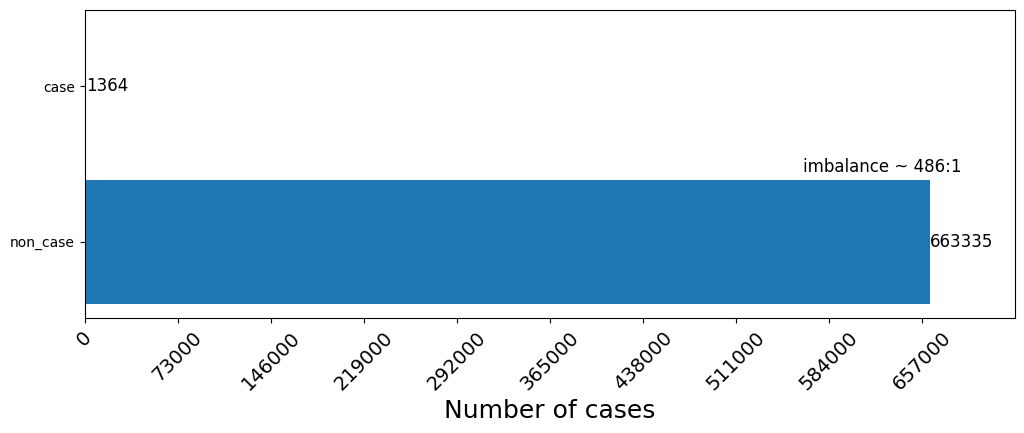

In [9]:
plot_imbalance(data_train, target_column='cases')

In [10]:
# plot_imbalance(data_test, target_column='cases')

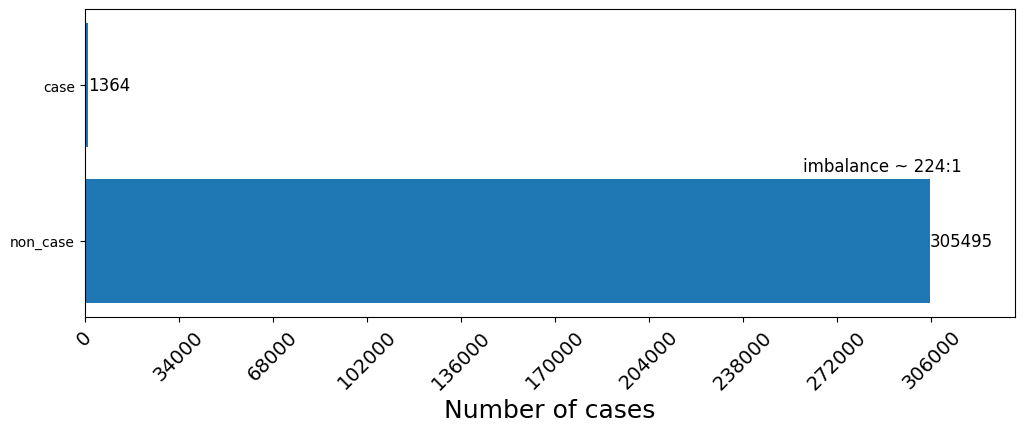

In [11]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [12]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

# plot_imbalance(data_test, target_column='cases')

In [13]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

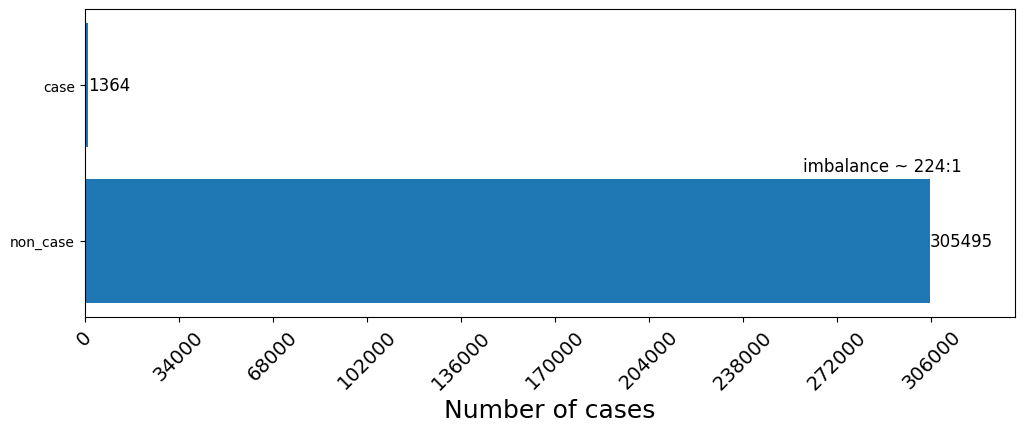

In [14]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [15]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

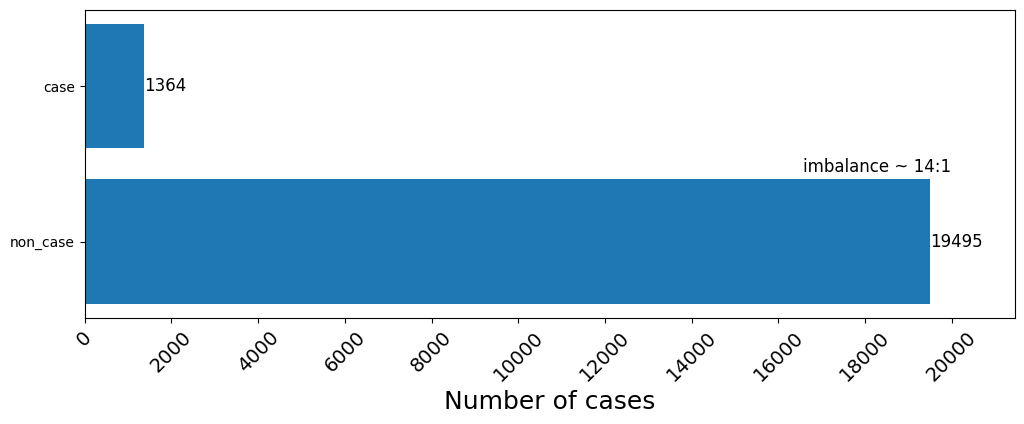

In [16]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [17]:
data_train.shape

(20720, 94)

In [18]:
data_train.cases.sum()

1364

In [19]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1651,262,1913,6.30%
1,2011,1605,100,1705,16.05%
2,2012,1615,157,1772,10.29%
3,2013,1658,85,1743,19.51%
4,2014,1556,15,1571,103.73%
5,2015,1647,0,1647,inf%
6,2016,1659,0,1659,inf%
7,2017,1588,42,1630,37.81%
8,2018,1570,296,1866,5.30%
9,2019,1651,218,1869,7.57%


In [20]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [21]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 14.29
Weight: 14.29


In [22]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [23]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL52,EL524,εδεσσας,2023,5,21.76334,40.79806,0.319322,-0.076500,-0.317251,0.076500,0.322927,-0.083578,-0.325686,0.083578,0.018813,0.018785,0.016366,0.018785,15.713571,8.044074,8.507143,13.895161,15.713571,4.140000,1.112963,-0.015714,4.273226,4.140000,9.926786,4.578519,4.245714,9.084194,9.926786,1.15,22.59,0.337156,0.152347,2.618662,10.114669,83.479429,14.000000,21.833333,48.518519,876.978283,36.0,-9.0,45.0,24.666667,4.666667,24.666667,3.166667,1205.0,182.0,3.0,61.218396,493.0,94.0,493.0,173.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
1,1,EL52,EL524,εδεσσας,2023,5,21.76334,40.81603,0.346775,-0.107114,-0.383770,0.107114,0.327361,-0.116990,-0.364363,0.116990,0.015227,0.016500,0.014715,0.016500,17.157143,8.684074,8.967857,15.106774,17.157143,2.577143,-0.477407,-1.907857,2.356452,2.577143,9.867143,4.103333,3.530000,8.731613,9.867143,0.61,23.71,2.261519,0.288895,56.285175,67.845571,202.619089,12.708333,23.083333,50.181159,759.023995,34.0,-12.0,46.0,22.333333,4.166667,22.333333,3.166667,1246.0,242.0,2.0,65.733663,504.0,51.0,504.0,127.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
2,2,EL52,EL524,εδεσσας,2023,5,21.76334,40.83400,0.288495,-0.056716,-0.341119,0.056716,0.342186,-0.080730,-0.374723,0.080730,0.031510,0.040679,0.020554,0.040679,15.328571,6.318889,6.463571,15.433871,15.328571,1.254286,-1.719630,-3.611429,1.156452,1.254286,8.291429,2.299630,1.426071,8.295161,8.291429,-1.23,22.95,2.261519,0.288895,56.285175,67.845571,202.619089,11.958333,22.416667,48.731884,754.217937,33.0,-13.0,46.0,21.166667,5.500000,21.166667,2.333333,1246.0,242.0,2.0,65.733663,504.0,51.0,504.0,268.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
3,3,EL52,EL524,εδεσσας,2023,5,21.76334,40.85196,0.274804,-0.107608,-0.323766,0.107608,0.296651,-0.100984,-0.342124,0.100984,0.030673,0.040773,0.040697,0.040773,15.582143,6.254444,5.096429,13.691935,15.582143,4.946429,-1.861852,1.691429,2.028065,4.946429,10.264286,2.196296,3.393929,7.860000,10.264286,1.57,19.95,2.261519,0.288895,56.285175,67.845571,202.619089,10.291667,21.750000,49.431818,766.473131,30.0,-14.0,44.0,18.833333,4.500000,18.833333,-0.166667,1246.0,242.0,2.0,65.733663,504.0,51.0,504.0,268.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,8752.0,39332.0,14000.0,62084.0,8343.0,38438.0,17398.0,64179.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
4,4,EL52,EL524,εδεσσας,2023,5,21.78676,40.79806,-0.125319,0.259979,0.351772,-0.259979,-0.021133,0.172482,0.206148,-0.172482,0.178791,0.155013,0.260687,0.155013,15.149286,8.347778,8.057857,12.670645,15.149286,

### Results 2023 ###

In [24]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_may['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [25]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jun['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jul['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_aug['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_sep['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_oct['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1301,1301,EL52,EL521,αλεξανδρειας,2023,5,22.51286,40.65433,0.012643
1244,1244,EL52,EL524,πελλας,2023,5,22.48944,40.76213,0.012228
1307,1307,EL52,EL524,πελλας,2023,5,22.51286,40.76213,0.010648
1182,1182,EL52,EL524,πελλας,2023,5,22.46601,40.74416,0.010250
1363,1363,EL52,EL521,αλεξανδρειας,2023,5,22.53628,40.61840,0.009654


In [31]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1244,1244,EL52,EL524,πελλας,2023,6,22.48944,40.76213,0.117408
1980,1980,EL52,EL522,κορδελιου ευοσμου,2023,6,22.91104,40.67230,0.084307
1182,1182,EL52,EL524,πελλας,2023,6,22.46601,40.74416,0.067796
1119,1119,EL52,EL524,πελλας,2023,6,22.44259,40.69026,0.053243
2966,2966,EL52,EL527,νεας προποντιδας,2023,6,23.33265,40.25906,0.051978


In [32]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
555,555,EL52,EL521,βεροιας,2023,7,22.20837,40.52856,0.911248
1066,1066,EL52,EL524,πελλας,2023,7,22.41917,40.79806,0.903616
321,321,EL52,EL524,αλμωπιας,2023,7,22.06783,41.03163,0.889568
3100,3100,EL52,EL527,πολυγυρου,2023,7,23.37949,40.33093,0.889073
3097,3097,EL52,EL527,κασσανδρας,2023,7,23.37949,40.11533,0.845065


In [33]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2966,2966,EL52,EL527,νεας προποντιδας,2023,8,23.33265,40.25906,0.952694
2969,2969,EL52,EL527,πολυγυρου,2023,8,23.33265,40.31296,0.951558
3231,3231,EL52,EL527,κασσανδρας,2023,8,23.42634,40.04346,0.951112
1066,1066,EL52,EL524,πελλας,2023,8,22.41917,40.79806,0.946644
3168,3168,EL52,EL527,πολυγυρου,2023,8,23.40292,40.31296,0.943405


In [34]:
results_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3168,3168,EL52,EL527,πολυγυρου,2023,9,23.40292,40.31296,0.916998
1371,1371,EL52,EL524,πελλας,2023,9,22.53628,40.76213,0.911862
3097,3097,EL52,EL527,κασσανδρας,2023,9,23.37949,40.11533,0.911358
3410,3410,EL52,EL526,σερρων,2023,9,23.47318,41.10350,0.898801
1066,1066,EL52,EL524,πελλας,2023,9,22.41917,40.79806,0.891317


In [35]:
results_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3474,3474,EL52,EL526,σερρων,2023,10,23.49661,41.10350,0.356091
3097,3097,EL52,EL527,κασσανδρας,2023,10,23.37949,40.11533,0.333431
3363,3363,EL52,EL527,κασσανδρας,2023,10,23.47318,40.02550,0.308680
3880,3880,EL52,EL527,κασσανδρας,2023,10,23.66057,39.93566,0.232630
3299,3299,EL52,EL527,πολυγυρου,2023,10,23.44976,40.29500,0.231705


In [36]:
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"
cm_grid = gpd.read_file(r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [37]:
cm_grid.head()

,cell_numbe,NUTS2_ID,x,y,geometry
0,0,EL52,21.76334,40.79806,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,21.76334,40.81603,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,21.76334,40.83400,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,21.76334,40.85196,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,21.78676,40.79806,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [38]:
greece_nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [39]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [40]:
greece_lakes.head()

,objectid,EU_CD,MS_CD,NAME,ALTNAME1,ALTNAME2,ALTNAME3,BASIN_CD,CHARACTER_,shape_area,shape_len,geometry
0,1,GR001100030020H,001100030020H,????? ???????,KERKINI LAKE,None,None,11,Insufficient Data,46088780.0,70604.0100,"POLYGON ((23.08306 41.19977, 23.08406 41.20032..."
1,2,GR001200030030N,001200030030N,????? ????????,ISMARIDA LAKE,None,None,12,Insufficient Data,1865103.9,5520.0850,"POLYGON ((25.30798 40.99044, 25.30862 40.99215..."
2,3,GR000800030010H,000800030010H,??????? ????? ??????,KARLAS RESERVOIR,None,None,08,Insufficient Data,34925588.0,29704.8950,"POLYGON ((22.78068 39.49602, 22.78083 39.49649..."
3,4,GR000800030020H,000800030020H,??????? ????? ????????,SMOKOVO RESERVOIR,None,None,08,Insufficient Data,9917521.0,57610.2000,"POLYGON ((22.04919 39.10001, 22.05059 39.10001..."
4,5,GR001300030020N,001300030020N,????? ??????,KOURNA LAKE,None,None,13,No Risk,561666.4,2849.8203,"POLYGON ((24.27341 35.33136, 24.27384 35.33312..."


In [41]:
cm_grid = cm_grid.to_crs(epsg=4326)
cm_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
cm_grid = cm_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {cm_grid.crs}')

greece_index CRS: EPSG:4326


In [42]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == 'EL52']
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts2 CRS: EPSG:4326


In [43]:
greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME'], inplace=True)

wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου', 'Άθως']

greece_lau1 = greece_lau1[~greece_lau1['NAME'].isin(wrong_list)].copy()
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lau1 CRS: EPSG:4326


In [44]:
greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_lakes CRS: EPSG:4326


In [45]:
cm_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [46]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [47]:
greece_lau1.head()

,NAME,geometry
0,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
1,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
2,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
3,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
4,Αμφίπολης,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."


In [48]:
greece_lakes.head()

,name,area,length,geometry
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256..."
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087..."
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40..."
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179..."
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039..."


In [49]:
results_may = pd.merge(results_may, cm_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')

results_jun = pd.merge(results_jun, cm_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')

results_jul = pd.merge(results_jul, cm_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')

results_aug = pd.merge(results_aug, cm_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')

results_sep = pd.merge(results_sep, cm_grid, on='cell_number', how='left')
results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')

results_oct = pd.merge(results_oct, cm_grid, on='cell_number', how='left')
results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')

In [50]:
float_column = 'score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm

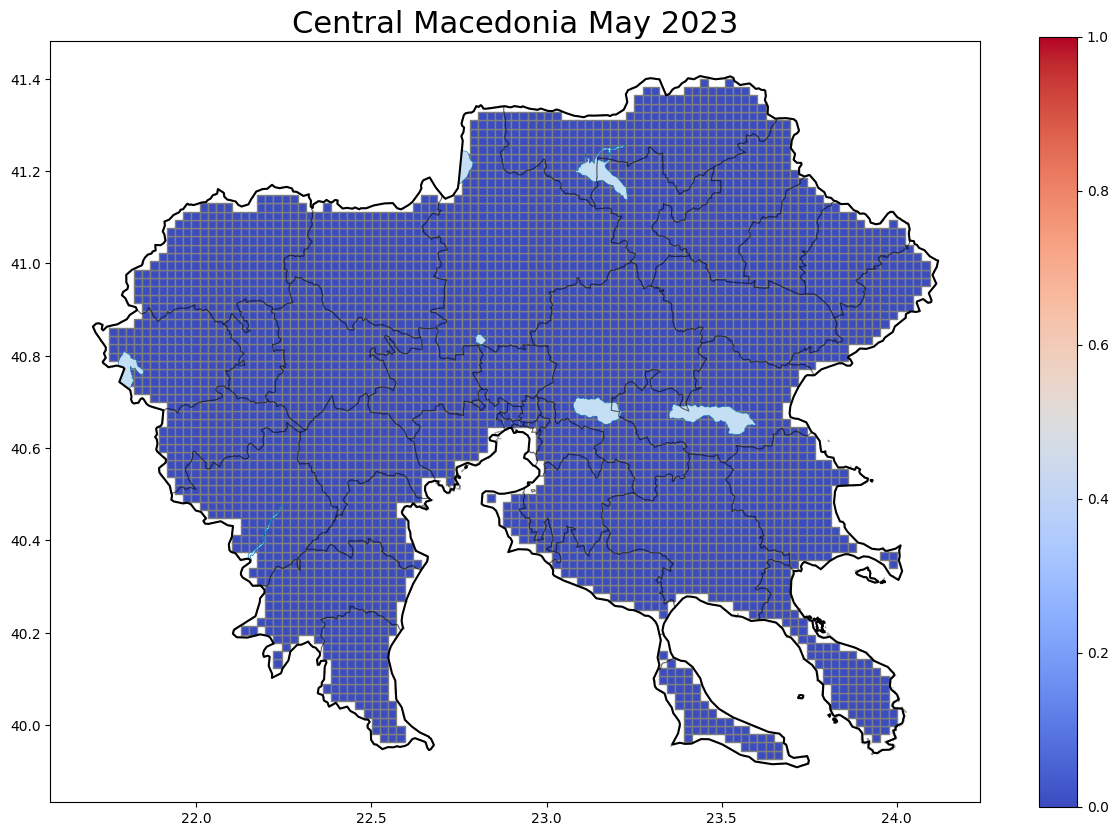

In [51]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia May {TEST_YEAR}', size = 22)
plt.show()

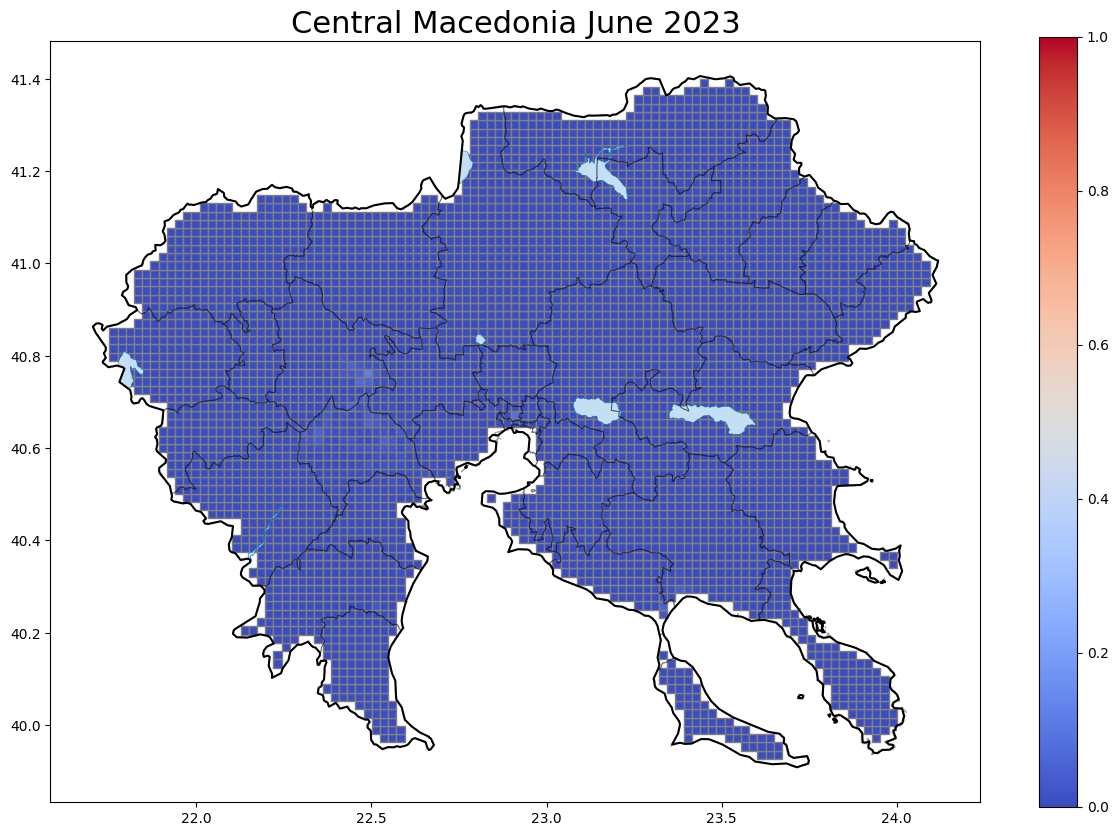

In [52]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia June {TEST_YEAR}', size = 22)
plt.show()

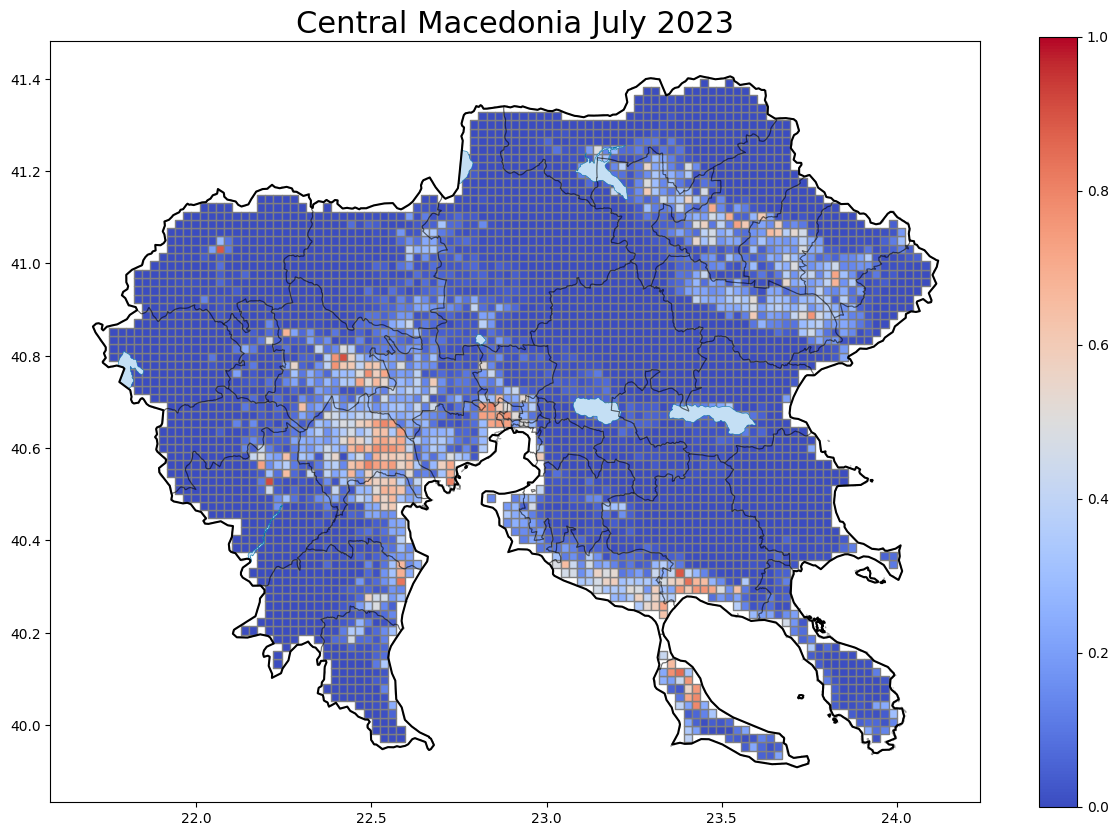

In [53]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia July {TEST_YEAR}', size = 22)
plt.show()

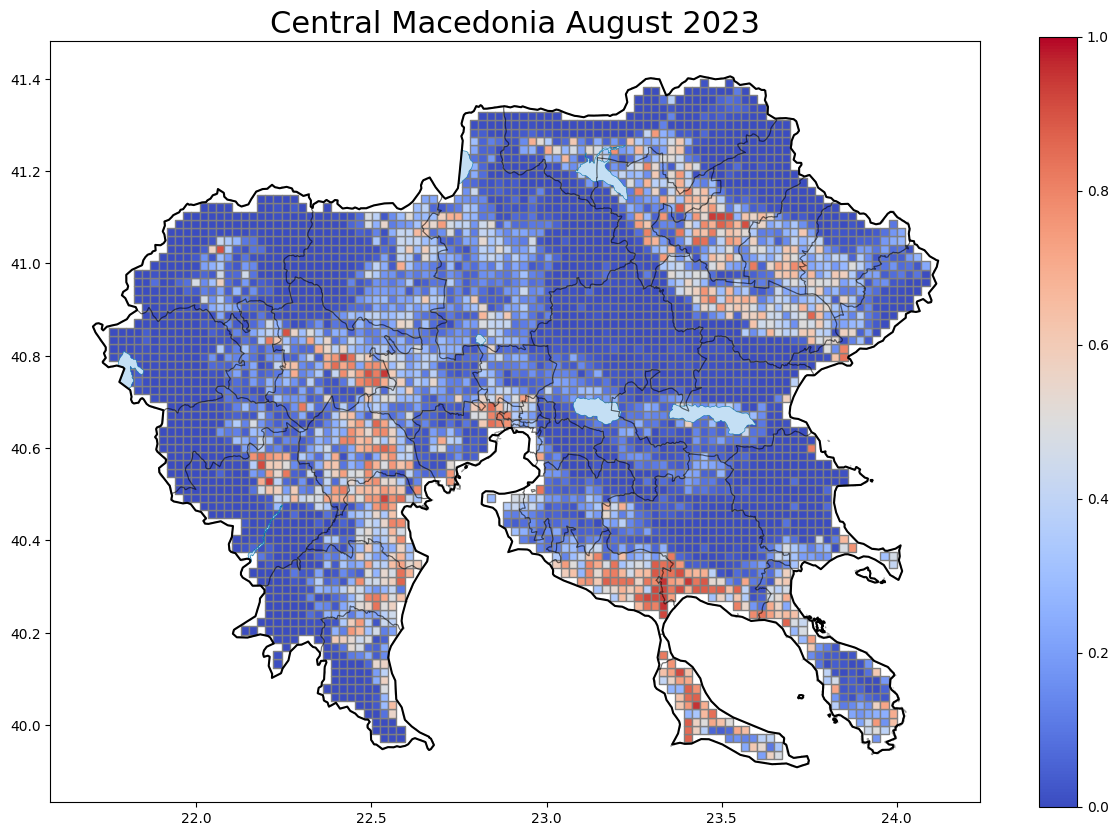

In [54]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia August {TEST_YEAR}', size = 22)
plt.show()

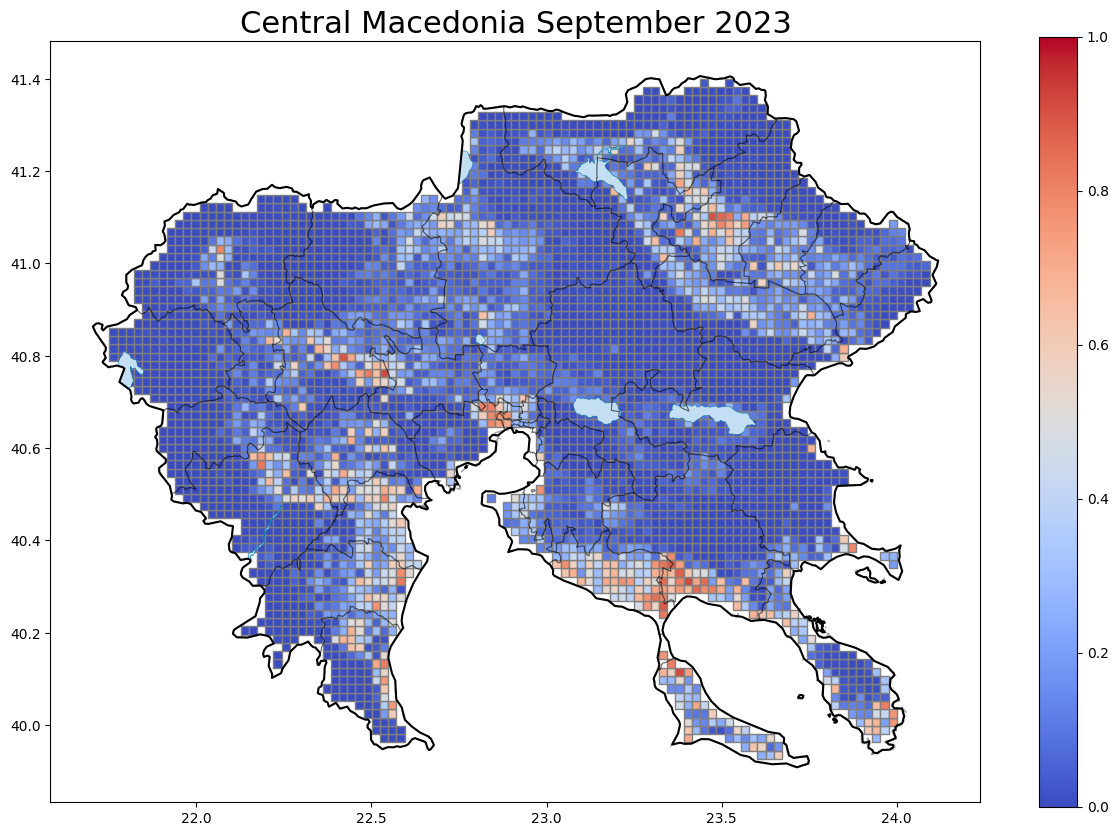

In [55]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia September {TEST_YEAR}', size = 22)
plt.show()

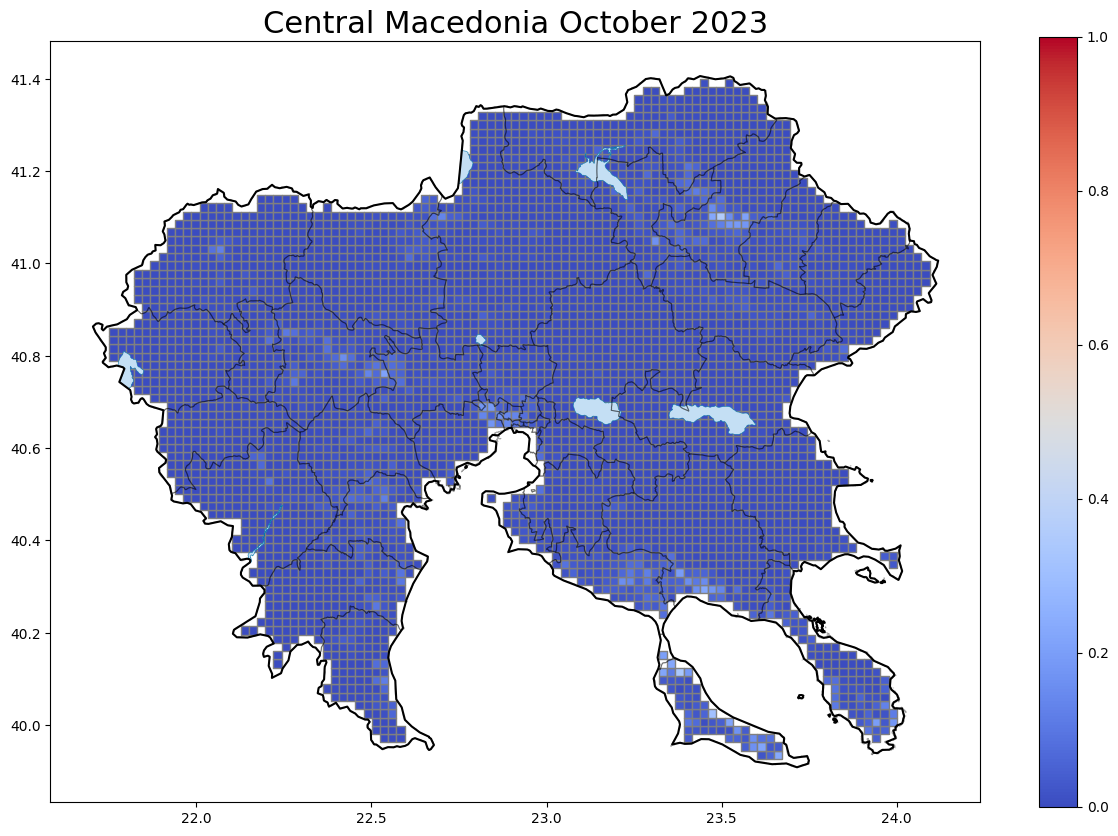

In [56]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia October {TEST_YEAR}', size = 22)
plt.show()